# Task 3: Heart Disease Prediction
**DevelopersHub Corporation — AI/ML Engineering Internship**

## 1. Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


2. Load Dataset from CSV

In [34]:
# ── Load the CSV file ─────────────────────────────────────────────────────
df = pd.read_csv('heart.csv')

print(f"✅ Dataset loaded successfully!")
print(f"   Shape   : {df.shape}  (rows × columns)")
print(f"   Columns : {list(df.columns)}")
print()
display(df.head(10))


✅ Dataset loaded successfully!
   Shape   : (303, 14)  (rows × columns)
   Columns : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,160,211,0,1,150,1,1.1,1,3,3,0
1,67,1,4,137,279,0,0,169,0,1.3,1,0,3,0
2,67,1,4,147,222,0,1,162,0,3.4,2,0,3,0
3,37,1,3,169,177,0,2,125,0,0.5,2,0,7,0
4,41,0,2,162,177,0,1,130,0,0.4,2,0,7,0
5,56,1,2,114,281,0,1,156,0,0.0,1,1,3,1
6,62,0,4,147,237,0,0,140,0,0.2,2,1,7,1
7,57,1,4,128,239,0,0,142,1,0.3,1,0,3,0
8,63,1,4,129,300,1,0,162,1,0.2,2,0,7,1
9,53,1,4,137,188,0,0,127,0,1.4,1,0,7,1


## 3. Data Inspection & Cleaning

In [35]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [36]:
print("=== Missing Values per Column ===")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

# Fill any missing values with column median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  Filled '{col}' with median = {median_val:.1f}")

print("\n✅ Dataset is clean — ready for analysis!")


=== Missing Values per Column ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

✅ Dataset is clean — ready for analysis!


In [37]:
print("=== Descriptive Statistics ===")
display(df.describe().round(2))


=== Descriptive Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,52.94,0.88,3.34,131.05,238.21,0.17,0.58,149.40,0.32,1.06,2.03,0.69,4.84,0.52
std,8.36,0.33,1.01,16.95,50.02,0.37,0.57,21.07,0.47,1.05,0.63,0.98,1.93,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,87.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,46.00,1.00,3.00,119.00,207.00,0.00,0.00,135.00,0.00,0.30,2.00,0.00,3.00,0.00
50%,54.00,1.00,4.00,131.00,239.00,0.00,1.00,150.00,0.00,0.70,2.00,0.00,3.00,1.00
75%,58.00,1.00,4.00,142.00,271.50,0.00,1.00,162.00,1.00,1.40,2.00,1.00,7.00,1.00
max,71.00,1.00,4.00,171.00,383.00,1.00,2.00,202.00,1.00,5.50,3.00,3.00,7.00,1.00


In [38]:
print("=== Target Class Distribution ===")
counts = df['target'].value_counts().sort_index()
total  = len(df)
print(f"  No Heart Disease (0) : {counts[0]:>3} patients  ({counts[0]/total*100:.1f}%)")
print(f"  Heart Disease    (1) : {counts[1]:>3} patients  ({counts[1]/total*100:.1f}%)")
print(f"  Total            : {total} patients")


=== Target Class Distribution ===
  No Heart Disease (0) : 145 patients  (47.9%)
  Heart Disease    (1) : 158 patients  (52.1%)
  Total            : 303 patients


In [39]:
# Per-group mean — shows how features differ between sick and healthy
print("=== Feature Means — Healthy vs Diseased ===")
display(df.groupby('target').mean().round(2).T)


=== Feature Means — Healthy vs Diseased ===


target,0,1
age,53.59,52.34
sex,0.89,0.87
cp,3.32,3.36
trestbps,130.85,131.23
chol,233.19,242.81
fbs,0.17,0.16
restecg,0.63,0.53
thalach,149.66,149.17
exang,0.30,0.35
oldpeak,1.07,1.04


## 4. Exploratory Data Analysis (EDA)

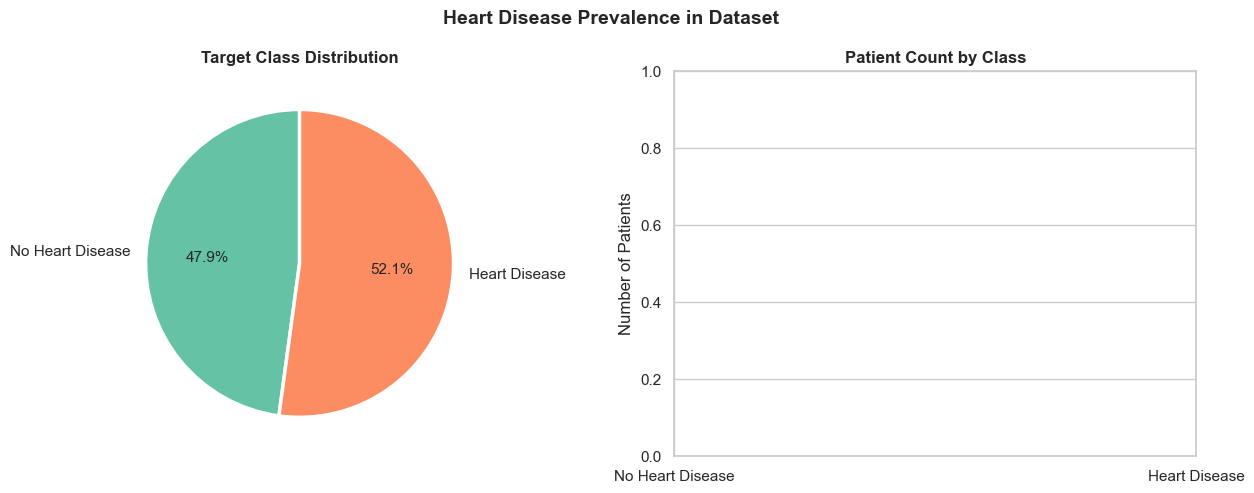

Saved: task3_target_dist.png


In [40]:
# ── Target distribution ───────────────────────────────────────────────────
COLORS = ['#66c2a5', '#fc8d62']
LABELS = ['No Heart Disease', 'Heart Disease']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['target'].value_counts().sort_index()

axes[0].pie(counts.values, labels=LABELS, colors=COLORS,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2.5))
axes[0].set_title('Target Class Distribution', fontweight='bold')


df_plot = df.copy()
df_plot['target'] = df_plot['target'].astype(str)
palette={'0': COLORS[0], '1': COLORS[1]}
# sns.countplot(ax=axes[1], data=df, x='target',
             # palette={0: COLORS[0], 1: COLORS[1]}, edgecolor='white')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(LABELS)
axes[1].set_title('Patient Count by Class', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Number of Patients')

for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 f'{int(bar.get_height())}',
                 ha='center', fontweight='bold')

plt.suptitle('Heart Disease Prevalence in Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task3_target_dist.png")


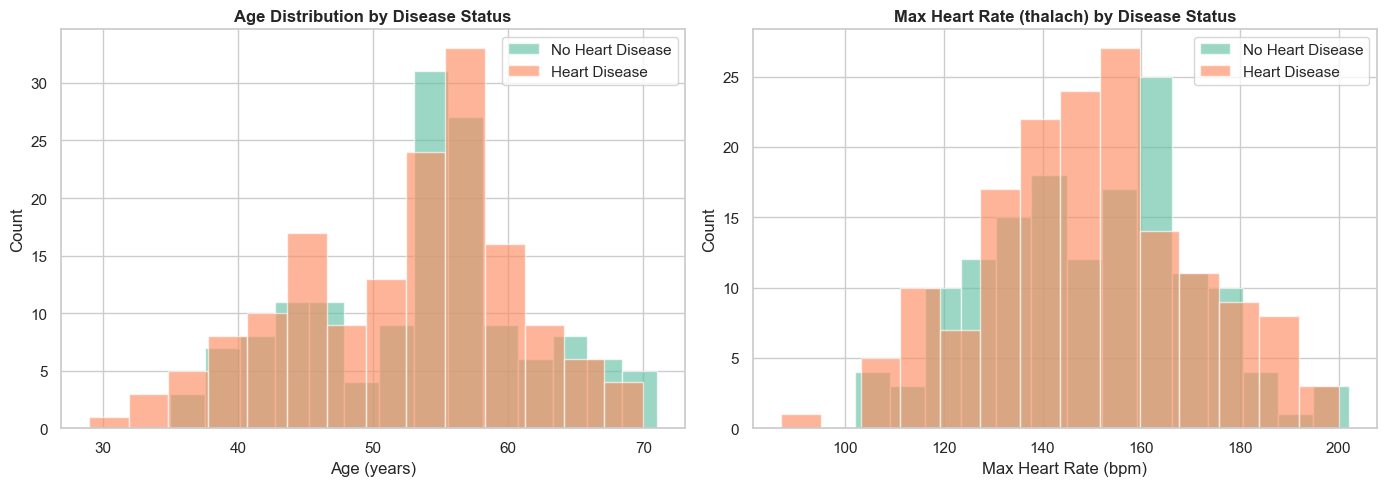

Saved: task3_age_thalach.png


In [41]:
# ── Age & Max Heart Rate by disease status ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, color, label in zip([0, 1], COLORS, LABELS):
    sub = df[df['target'] == val]
    axes[0].hist(sub['age'],     bins=14, alpha=0.65, color=color,
                 label=label, edgecolor='white')
    axes[1].hist(sub['thalach'], bins=14, alpha=0.65, color=color,
                 label=label, edgecolor='white')

axes[0].set_title('Age Distribution by Disease Status', fontweight='bold')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].set_title('Max Heart Rate (thalach) by Disease Status', fontweight='bold')
axes[1].set_xlabel('Max Heart Rate (bpm)'); axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('task3_age_thalach.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task3_age_thalach.png")


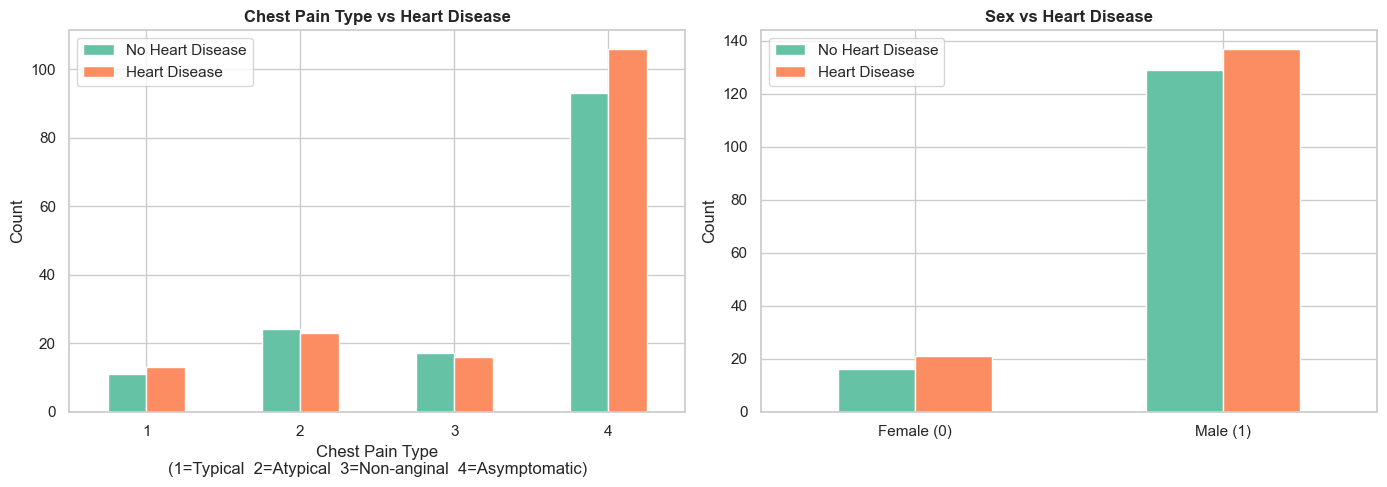

Saved: task3_cp_sex.png


In [42]:
# ── Chest pain type & Sex breakdown ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chest pain type
cp_df = df.groupby(['cp', 'target']).size().unstack(fill_value=0)
cp_df.columns = LABELS
cp_df.plot(kind='bar', ax=axes[0], color=COLORS, edgecolor='white', rot=0)
axes[0].set_title('Chest Pain Type vs Heart Disease', fontweight='bold')
axes[0].set_xlabel('Chest Pain Type\n(1=Typical  2=Atypical  3=Non-anginal  4=Asymptomatic)')
axes[0].set_ylabel('Count')

# Sex breakdown
sex_df = df.groupby(['sex', 'target']).size().unstack(fill_value=0)
sex_df.index = ['Female (0)', 'Male (1)']
sex_df.columns = LABELS
sex_df.plot(kind='bar', ax=axes[1], color=COLORS, edgecolor='white', rot=0)
axes[1].set_title('Sex vs Heart Disease', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('task3_cp_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task3_cp_sex.png")


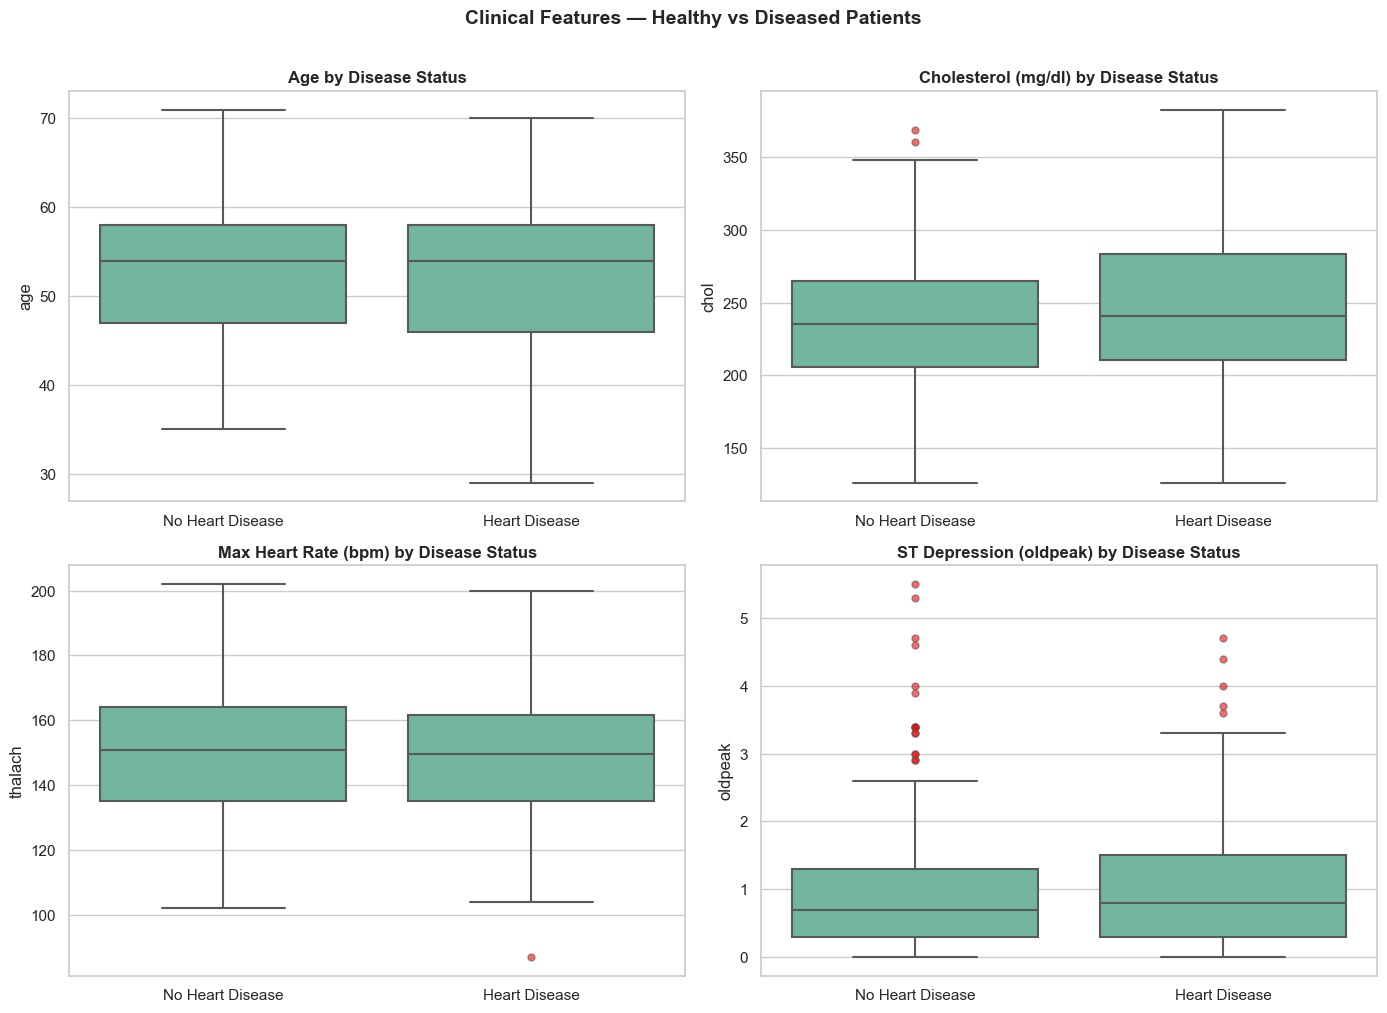

Saved: task3_boxplots.png


In [45]:
# target ko int me convert karo pehle
df['target'] = df['target'].astype(int)

# ── Box plots for key clinical features ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

key_feats = ['age', 'chol', 'thalach', 'oldpeak']
titles    = ['Age', 'Cholesterol (mg/dl)',
             'Max Heart Rate (bpm)', 'ST Depression (oldpeak)']

for ax, feat, title in zip(axes.flatten(), key_feats, titles):
    sns.boxplot(
        ax=ax,
        data=df,
        x='target',
        y=feat,
        linewidth=1.5,
        flierprops=dict(marker='o', markerfacecolor='red',
                        markersize=5, alpha=0.6)
    )
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(LABELS)
    ax.set_title(f'{title} by Disease Status', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Clinical Features — Healthy vs Diseased Patients',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('task3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: task3_boxplots.png")

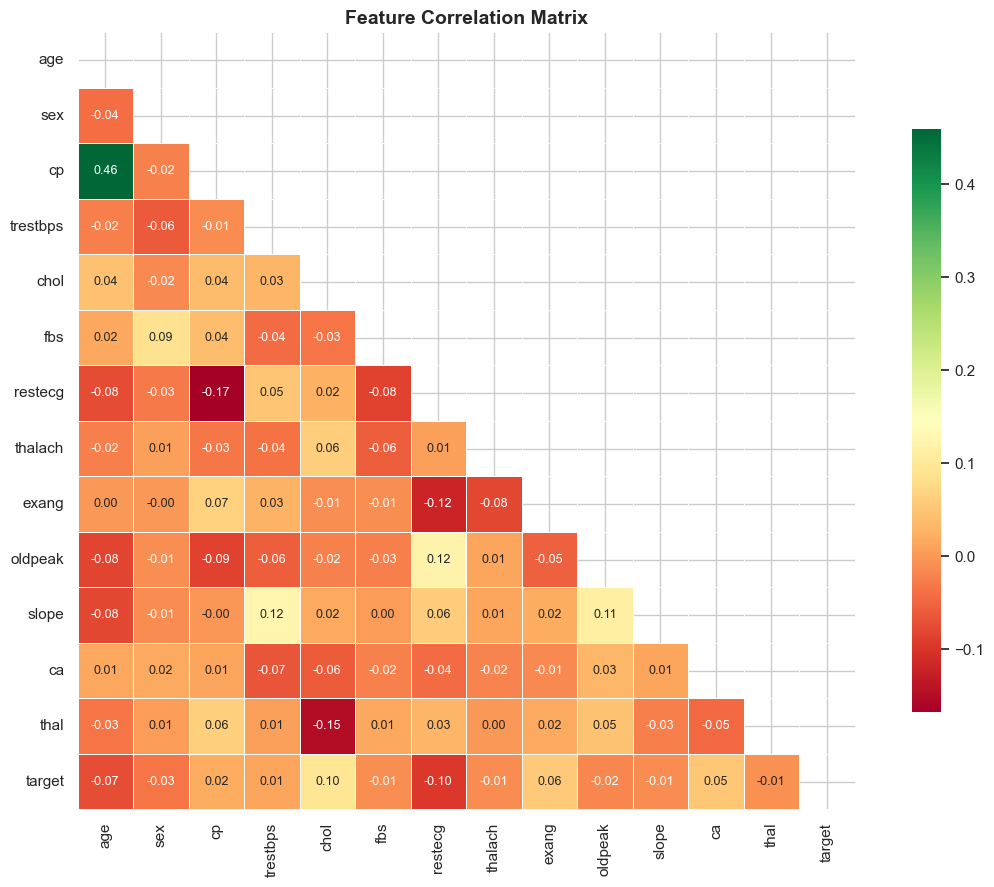

Saved: task3_correlation.png


In [46]:
# ── Correlation Heatmap ────────────────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            annot_kws={"size": 9})

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task3_correlation.png")


## 5. Model Training

In [47]:
# ── Features & Target ─────────────────────────────────────────────────────
X = df.drop('target', axis=1)
y = df['target']

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Features used        : {list(X.columns)}")

# ── Stratified 80/20 split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"\nClass balance in test set:")
print(f"  No Disease : {(y_test==0).sum()}")
print(f"  Disease    : {(y_test==1).sum()}")

# ── Standard Scaling ──────────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Data scaled using StandardScaler!")


Feature matrix shape : (303, 13)
Target shape         : (303,)
Features used        : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Training samples : 242
Testing  samples : 61

Class balance in test set:
  No Disease : 29
  Disease    : 32

✅ Data scaled using StandardScaler!


In [48]:
# ── Train all 3 models ───────────────────────────────────────────────────

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
print("✅ Logistic Regression trained")

# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
print("✅ Decision Tree trained")

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
print("✅ Random Forest trained")

print("\n✅ All three models trained successfully!")


✅ Logistic Regression trained
✅ Decision Tree trained
✅ Random Forest trained

✅ All three models trained successfully!


## 6. Model Evaluation

In [49]:
def evaluate_model(name, model, X_te, y_te, X_tr, y_tr):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, y_prob)
    cv_acc = cross_val_score(model, X_tr, y_tr,
                             cv=5, scoring='accuracy').mean()

    print(f"\n{'═'*50}")
    print(f"  Model          : {name}")
    print(f"  Test Accuracy  : {acc*100:.2f}%")
    print(f"  ROC-AUC Score  : {auc:.4f}")
    print(f"  CV Accuracy    : {cv_acc*100:.2f}%  (5-fold cross-val)")
    print(f"{'─'*50}")
    print(classification_report(y_te, y_pred,
          target_names=['No Disease', 'Heart Disease']))
    return y_pred, y_prob

pred_lr, prob_lr = evaluate_model("Logistic Regression", lr,
                                   X_test_sc, y_test,
                                   X_train_sc, y_train)
pred_dt, prob_dt = evaluate_model("Decision Tree",       dt,
                                   X_test_sc, y_test,
                                   X_train_sc, y_train)
pred_rf, prob_rf = evaluate_model("Random Forest",       rf,
                                   X_test_sc, y_test,
                                   X_train_sc, y_train)



══════════════════════════════════════════════════
  Model          : Logistic Regression
  Test Accuracy  : 45.90%
  ROC-AUC Score  : 0.5119
  CV Accuracy    : 49.22%  (5-fold cross-val)
──────────────────────────────────────────────────
               precision    recall  f1-score   support

   No Disease       0.41      0.31      0.35        29
Heart Disease       0.49      0.59      0.54        32

     accuracy                           0.46        61
    macro avg       0.45      0.45      0.44        61
 weighted avg       0.45      0.46      0.45        61


══════════════════════════════════════════════════
  Model          : Decision Tree
  Test Accuracy  : 47.54%
  ROC-AUC Score  : 0.4542
  CV Accuracy    : 48.35%  (5-fold cross-val)
──────────────────────────────────────────────────
               precision    recall  f1-score   support

   No Disease       0.46      0.55      0.50        29
Heart Disease       0.50      0.41      0.45        32

     accuracy             

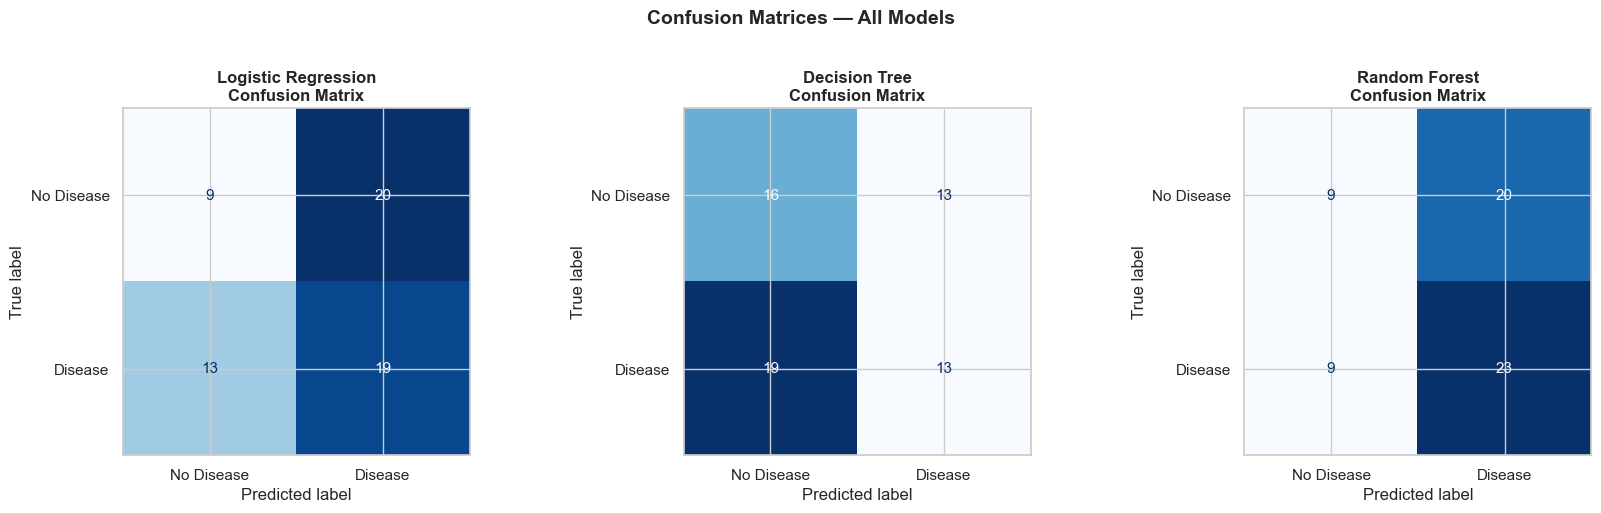

Saved: task3_confusion_matrices.png


In [50]:
# ── Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, pred) in zip(axes, [
        ("Logistic Regression", pred_lr),
        ("Decision Tree",       pred_dt),
        ("Random Forest",       pred_rf)]):

    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')

plt.suptitle('Confusion Matrices — All Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('task3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task3_confusion_matrices.png")


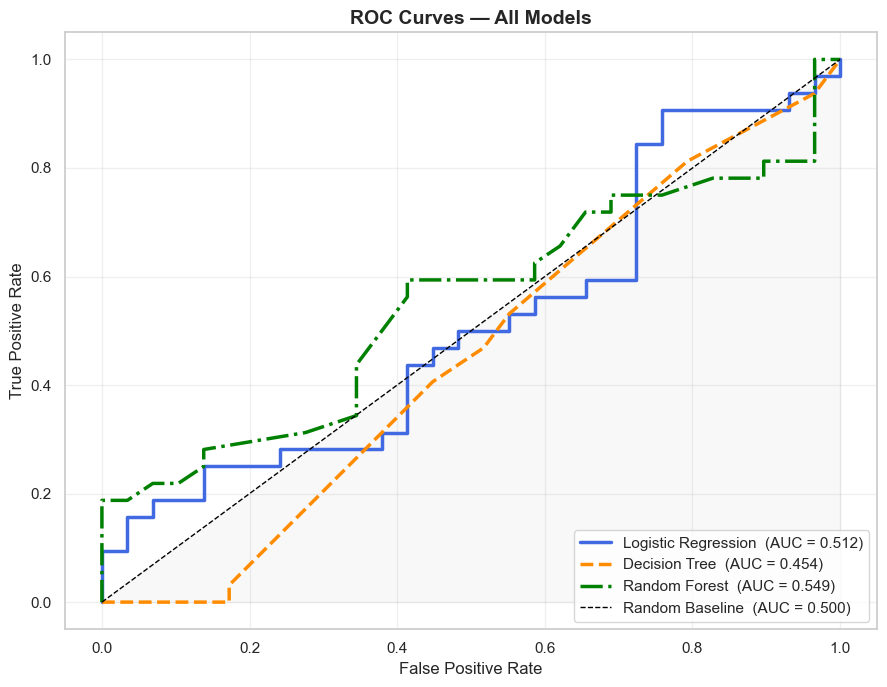

Saved: task3_roc_curves.png


In [51]:
# ── ROC Curves ────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))

for (name, prob), (color, ls) in zip(
        [("Logistic Regression", prob_lr),
         ("Decision Tree",       prob_dt),
         ("Random Forest",       prob_rf)],
        [('royalblue', '-'), ('darkorange', '--'), ('green', '-.')]):

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2.5, color=color,
             linestyle=ls, label=f'{name}  (AUC = {auc:.3f})')

plt.plot([0,1],[0,1], 'k--', linewidth=1,
         label='Random Baseline  (AUC = 0.500)')
plt.fill_between([0,1],[0,1], alpha=0.05, color='grey')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task3_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task3_roc_curves.png")


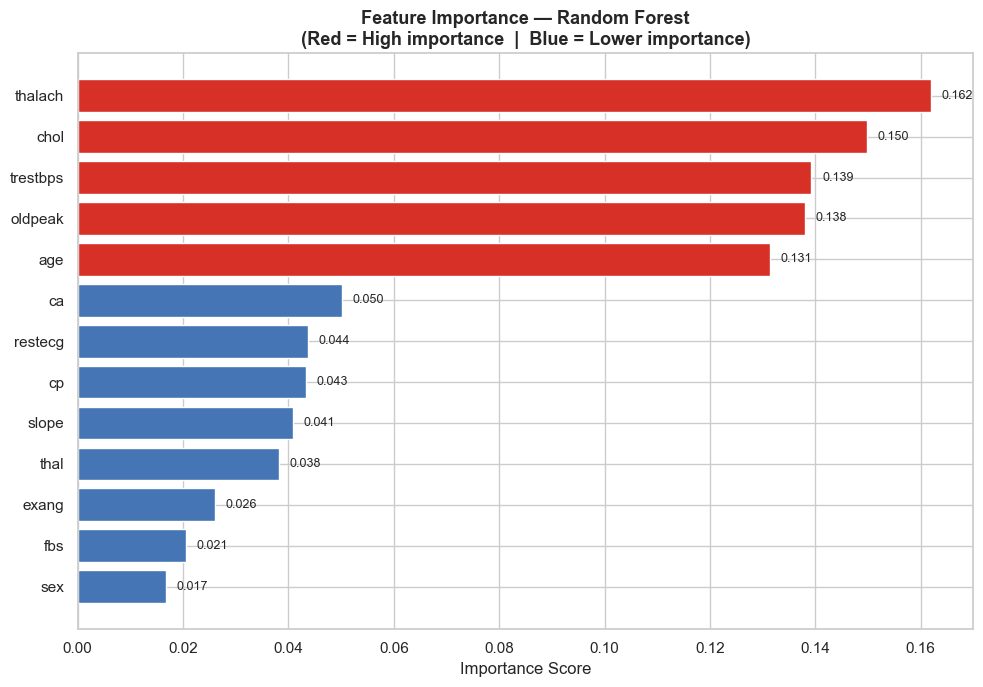

Top 5 Most Important Features:
 Feature  Importance
 thalach    0.161878
    chol    0.149716
trestbps    0.139269
 oldpeak    0.137986
     age    0.131398


In [52]:
# ── Feature Importance (Random Forest) ───────────────────────────────────
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df.sort_values('Importance', ascending=True, inplace=True)

bar_colors = ['#d73027' if v > 0.08 else '#4575b4'
              for v in feat_df['Importance']]

plt.figure(figsize=(10, 7))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'],
                color=bar_colors, edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.title('Feature Importance — Random Forest\n(Red = High importance  |  Blue = Lower importance)',
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('task3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 Most Important Features:")
print(feat_df.sort_values('Importance', ascending=False)
             .head(5).to_string(index=False))


In [53]:
# ── Model Performance Summary Table ─────────────────────────────────────
results = []
for name, model in [("Logistic Regression", lr),
                    ("Decision Tree",       dt),
                    ("Random Forest",       rf)]:
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    cv_acc = cross_val_score(model, X_train_sc, y_train,
                             cv=5, scoring='accuracy').mean()
    results.append({
        'Model'          : name,
        'Test Accuracy'  : f"{accuracy_score(y_test, y_pred)*100:.2f}%",
        'ROC-AUC'        : f"{roc_auc_score(y_test, y_prob):.4f}",
        'CV Accuracy'    : f"{cv_acc*100:.2f}%"
    })

summary = pd.DataFrame(results)
print("=== Model Performance Summary ===")
display(summary)


=== Model Performance Summary ===


,Model,Test Accuracy,ROC-AUC,CV Accuracy
0,Logistic Regression,45.90%,0.5119,49.22%
1,Decision Tree,47.54%,0.4542,48.35%
2,Random Forest,52.46%,0.5490,53.30%
